# 🛡️ XAI Credit Risk Scoring: Model Lifecycle

This notebook documents the end-to-end journey from raw data to a deployable, explainable ML model.

## 1. Exploratory Data Analysis (EDA)

In this section, we visualize the distributions and correlations of the Loan Default dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df_raw = pd.read_csv('../data/raw/Loan Default Prediction Dataset export 2026-04-13 19-55-23.csv')

print('Dataset Shape:', df_raw.shape)
df_raw.head()

Dataset Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


### Numerical Feature Distributions

Visualizing the distributions of core risk factors.

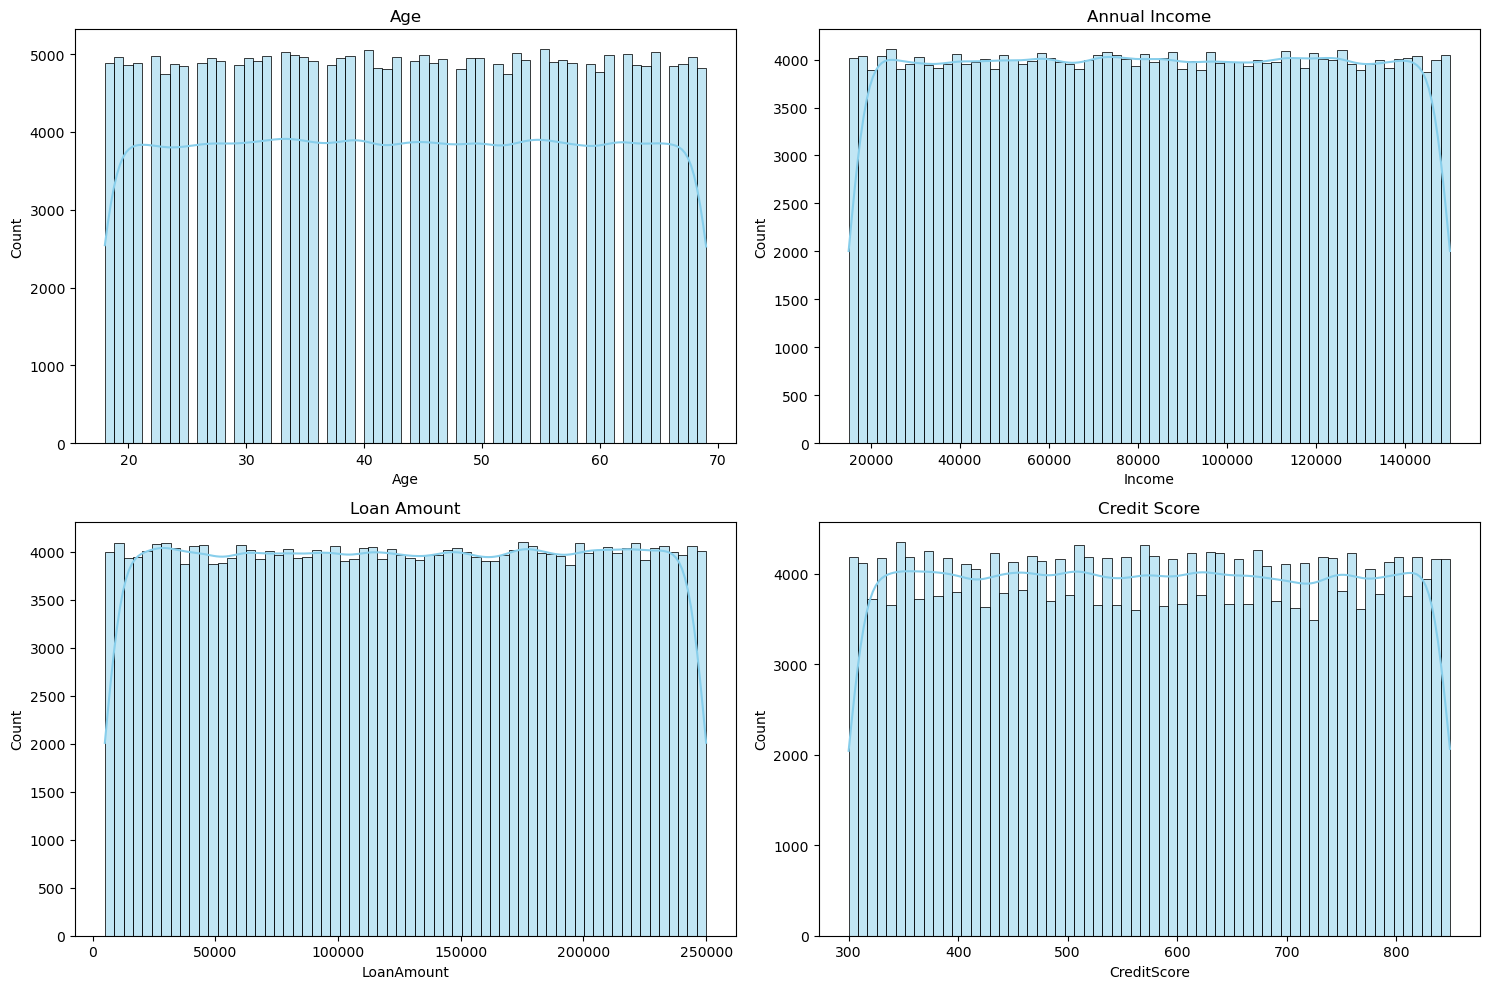

In [2]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore']
col_names = ['Age', 'Annual Income', 'Loan Amount', 'Credit Score']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col_names[i])
plt.tight_layout()
plt.show()

### Target Distribution

Analyzing the prevalence of loan defaults in the dataset.

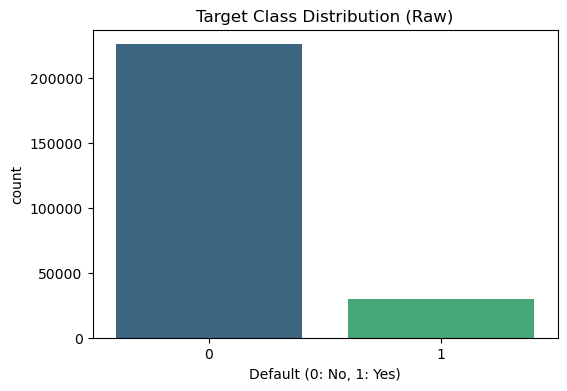

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df_raw, hue='Default', palette='viridis', legend=False)
plt.title('Target Class Distribution (Raw)')
plt.xlabel('Default (0: No, 1: Yes)')
plt.show()

### Correlation Heatmap

Visualizing relationships between numerical features and the default status.

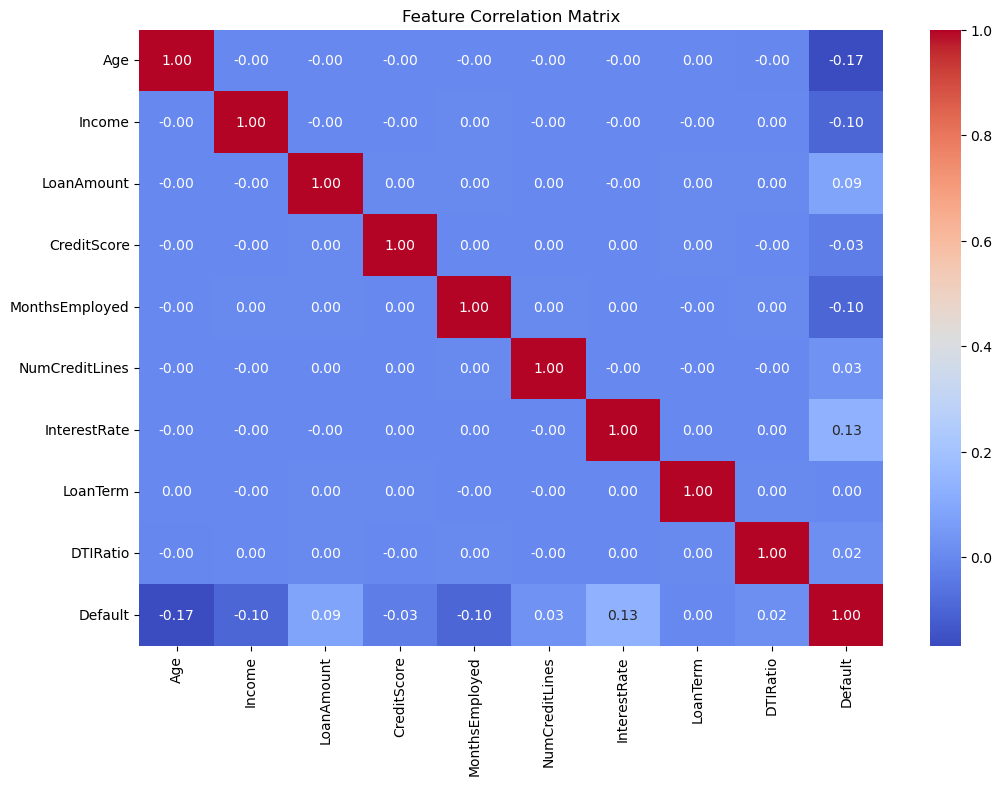

In [4]:
plt.figure(figsize=(12, 8))
numeric_df = df_raw.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 2. The Data Journey

From raw data to balanced training sets using One-Hot Encoding and SMOTE.

In [5]:
# Load processed data
X_train = pd.read_csv('../data/processed/loan_default_X_train.csv')
y_train = pd.read_csv('../data/processed/loan_default_y_train.csv').iloc[:, 0]
X_test = pd.read_csv('../data/processed/loan_default_X_test.csv')
y_test = pd.read_csv('../data/processed/loan_default_y_test.csv').iloc[:, 0]

print(f'Training set shape (Balanced): {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Training set shape (Balanced): (361110, 31)
Test set shape: (51070, 31)


### Class Distribution (Post-SMOTE)

Ensuring a 50/50 split between Good and Bad credit cases to avoid model bias.

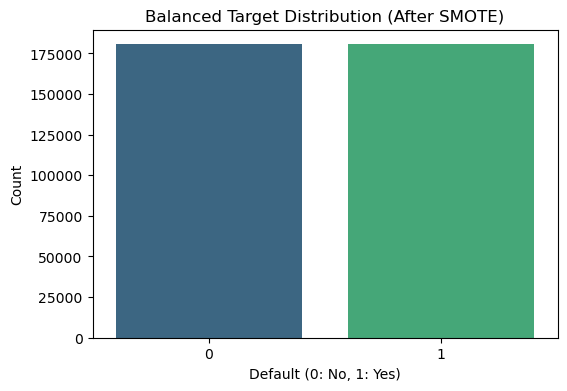

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette='viridis', legend=False)
plt.title('Balanced Target Distribution (After SMOTE)')
plt.xlabel('Default (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

## 3. The Model Showdown

Comparing Logistic Regression, Random Forest, Gradient Boosting, and XGBoost.

In [7]:
import joblib
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import pandas as pd

model = joblib.load('../models/best_model_xgboost.joblib')
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print('--- Winning Model: XGBoost ---')
print(f'AUC-ROC: {roc_auc_score(y_test, probs):.4f}')
print(f'F1-Score: {f1_score(y_test, preds):.4f}')
print('\nClassification Report:\n', classification_report(y_test, preds))

print('\n' + '='*40)
print('Final Model Comparison Table')
print('='*40)
results = {
    'LogisticRegression': {'AUC': 0.7531, 'F1': 0.3363, 'Precision': 0.2222, 'Recall': 0.6920},
    'RandomForest': {'AUC': 0.7429, 'F1': 0.1656, 'Precision': 0.4333, 'Recall': 0.1023},
    'GradientBoosting': {'AUC': 0.7530, 'F1': 0.1519, 'Precision': 0.5547, 'Recall': 0.0880},
    'XGBoost': {'AUC': 0.7539, 'F1': 0.1656, 'Precision': 0.5625, 'Recall': 0.0971}
}
df_results = pd.DataFrame(results).T
print(df_results)

--- Winning Model: XGBoost ---
AUC-ROC: 0.7539
F1-Score: 0.1656

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.56      0.10      0.17      5931

    accuracy                           0.89     51070
   macro avg       0.73      0.54      0.55     51070
weighted avg       0.85      0.89      0.85     51070


Final Model Comparison Table
                       AUC      F1  Precision  Recall
LogisticRegression  0.7531  0.3363     0.2222  0.6920
RandomForest        0.7429  0.1656     0.4333  0.1023
GradientBoosting    0.7530  0.1519     0.5547  0.0880
XGBoost             0.7539  0.1656     0.5625  0.0971


## 4. Global XAI: The 'Forest' View

Which features most influence the probability of default?

/usr/local/Caskroom/miniconda/base/envs/xai-credit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


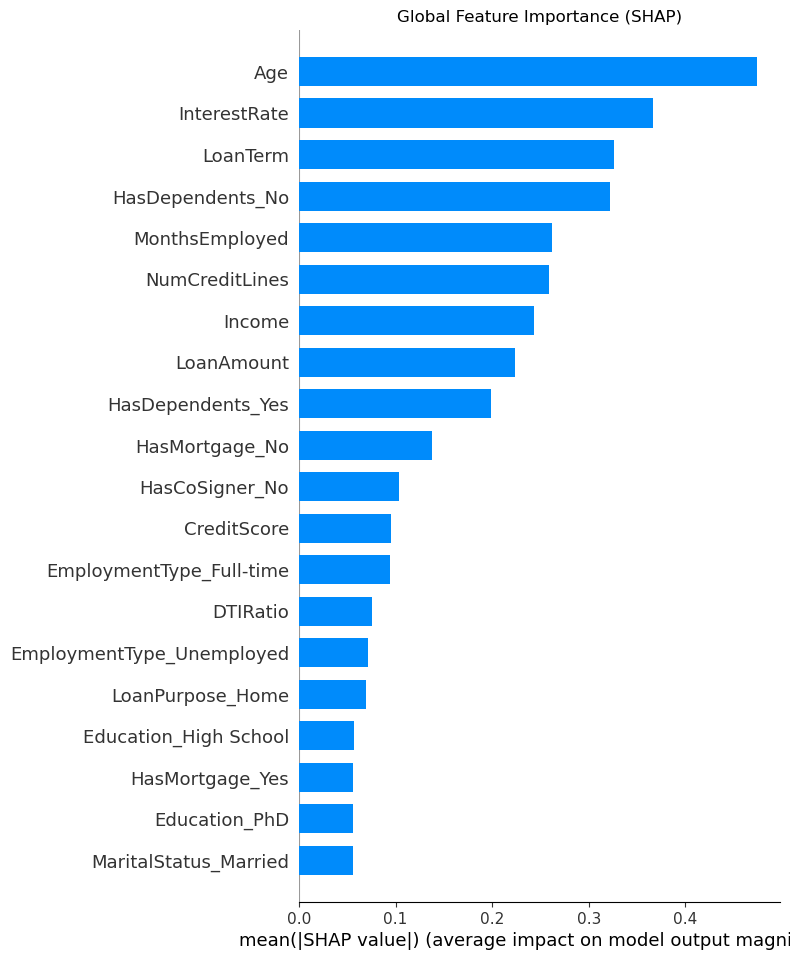

In [8]:
import shap
explainer = joblib.load('../models/shap_explainer.joblib')
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list): shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)')
plt.show()

### SHAP Beeswarm Plot

Visualizing the impact of specific feature values on risk.

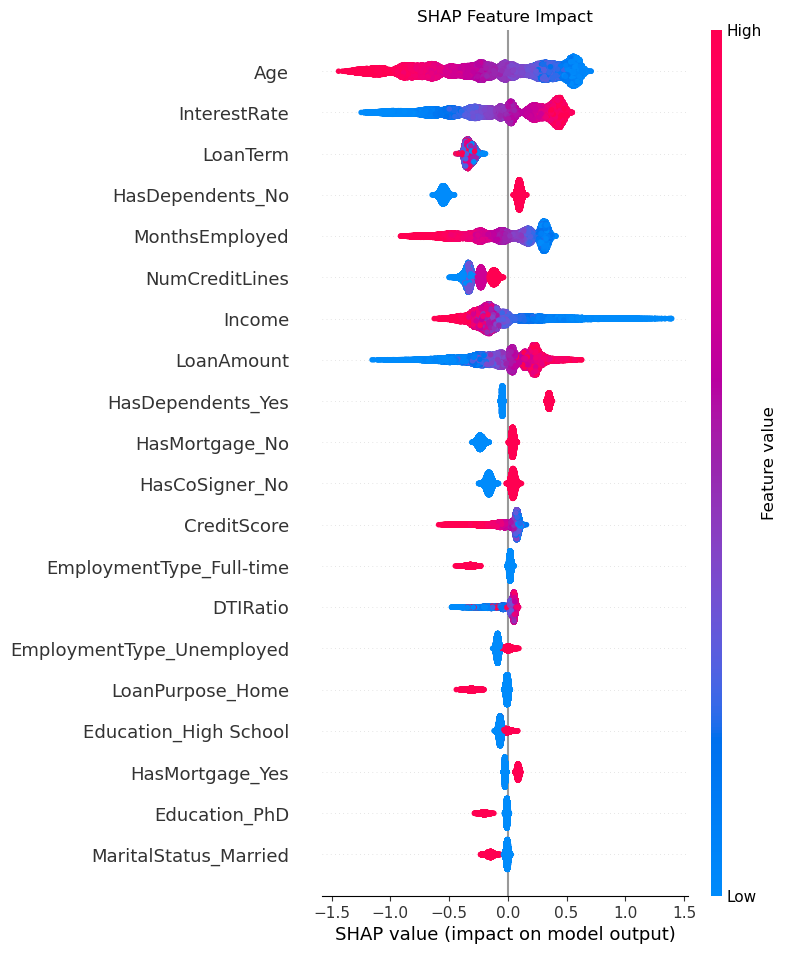

In [9]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Impact')
plt.show()

## 5. Local XAI: The 'Person' View

Explaining the decision for a single applicant.

Actual Default: 0
Predicted Default Probability: 5.98%


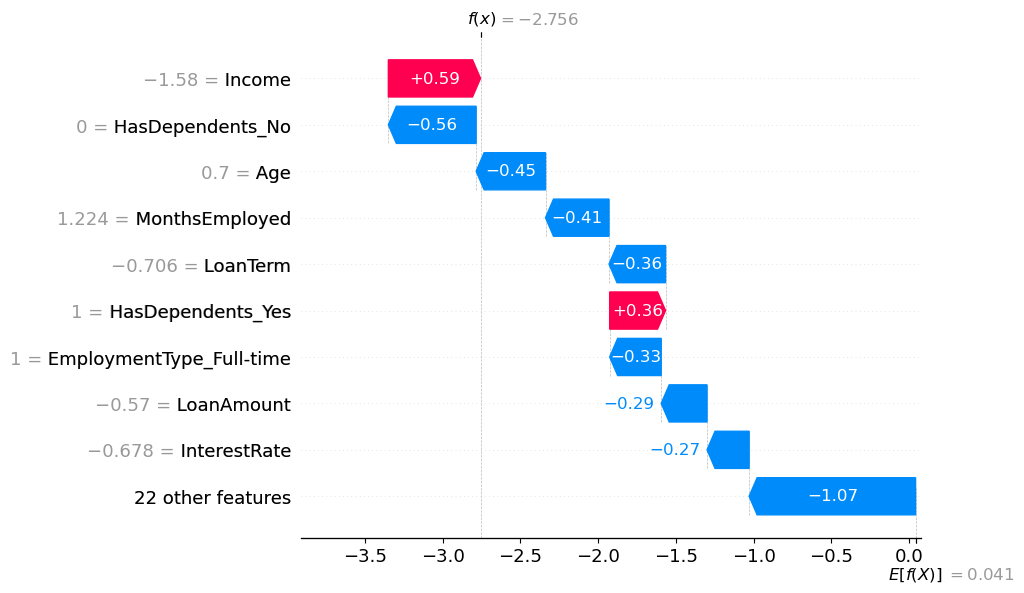

In [10]:
sample_idx = 0
person_data = X_test.iloc[sample_idx]
actual_class = y_test.iloc[sample_idx]
prob = model.predict_proba(person_data.to_frame().T)[0][1]

print(f'Actual Default: {actual_class}')
print(f'Predicted Default Probability: {prob:.2%}')

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explainer(X_test.iloc[sample_idx:sample_idx+1])[0])
plt.show()

## 6. Export & Persistence

Verification of the deployable artifacts.

In [11]:
import joblib

loaded_preprocessor = joblib.load('../models/preprocessor.joblib')
loaded_model = joblib.load('../models/best_model_xgboost.joblib')

print('✅ Artifacts loaded successfully.')
print(f'Preprocessor type: {type(loaded_preprocessor)}')
print(f'Model type: {type(loaded_model)}')

print('\nSystem ready for FastAPI deployment.')

✅ Artifacts loaded successfully.
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model type: <class 'xgboost.sklearn.XGBClassifier'>

System ready for FastAPI deployment.
